In [49]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import pytorch_lightning as L
import torchmetrics
import optuna
from optuna.integration import PyTorchLightningPruningCallback
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping
from lightning.pytorch.loggers import CSVLogger
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from collections import Counter

In [ ]:
NUM_CLASSES = 5
N_TRIALS = 10
HYP_EPOCHS = 10
TRAIN_EPOCHS = 35

In [51]:
class SHARPTrainDataset(Dataset):
    def __init__(self, root_dir, target_sets=['S1'], window_size=340, step_size=170):
        self.samples =[]
        #self.label_map = {'E': 0, 'W': 1, 'R': 2, 'J': 3, 'S': 4, 'C': 5, 'G': 6, 'H': 7} 8 activities
        self.label_map = {'E': 0, 'W': 1, 'R': 2, 'J': 3, 'S': 4} # 5 activities
        print(f"Loading training data for sets: {target_sets}...")
        for root, _, files in os.walk(root_dir):
            folder_name = os.path.basename(root)
            
            # Only process folders that start with our target sets (e.g., S1a, S1b match 'S1')
            if not any(folder_name.startswith(ts) for ts in target_sets):
                continue
                
            for file in files:
                if file.endswith(".txt"):
                    try:
                        code = file.split('_')[1][0].upper()
                        if code in self.label_map:
                            label = self.label_map[code]
                            data = np.load(os.path.join(root, file), allow_pickle=True).astype(np.float32)
                            
                            for start in range(0, data.shape[0] - window_size + 1, step_size):
                                window = data[start : start + window_size, :]
                                self.samples.append((window, label))
                    except Exception:
                        continue
        print(f"Loaded {len(self.samples)} train samples.")

    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        window, label = self.samples[idx]
        return torch.from_numpy(window).unsqueeze(0), torch.tensor(label, dtype=torch.long)
    
""" def __getitem__(self, idx):
        window, label = self.samples[idx]
        
        # --- THE NOISE GATE FIX ---
        # 1. Find the peak power in this specific 2-second window
        peak_power = np.max(window)
        
        # 2. Calculate the noise floor (12 dB below the peak, per the paper)
        noise_floor = peak_power - 12
        
        # 3. Zero out all background noise below the threshold
        # (If your baseline is, for example, -50, you can set it to -50 instead of 0)
        cleaned_window = np.where(window < noise_floor, 0, window) 
        
        return torch.from_numpy(cleaned_window).unsqueeze(0), torch.tensor(label, dtype=torch.long) """



' def __getitem__(self, idx):\n        window, label = self.samples[idx]\n        \n        # --- THE NOISE GATE FIX ---\n        # 1. Find the peak power in this specific 2-second window\n        peak_power = np.max(window)\n        \n        # 2. Calculate the noise floor (12 dB below the peak, per the paper)\n        noise_floor = peak_power - 12\n        \n        # 3. Zero out all background noise below the threshold\n        # (If your baseline is, for example, -50, you can set it to -50 instead of 0)\n        cleaned_window = np.where(window < noise_floor, 0, window) \n        \n        return torch.from_numpy(cleaned_window).unsqueeze(0), torch.tensor(label, dtype=torch.long) '

In [52]:
class SHARPTestDataset(Dataset):
    def __init__(self, root_dir, target_sets, window_size=340, step_size=170):
        self.samples = []
        self.label_map = {'E': 0, 'W': 1, 'R': 2, 'J': 3, 'S': 4}

        for root, _, files in os.walk(root_dir):
            folder_name = os.path.basename(root)
            if not any(folder_name.startswith(ts) for ts in target_sets):
                continue

            for file in files:
                if file.endswith("stream_0.txt"): 
                    try:
                        code = file.split('_')[1][0].upper()
                        if code in self.label_map:
                            label = self.label_map[code]
                            base_path = os.path.join(root, file.replace("_stream_0.txt", ""))
                            
                            streams = []
                            for i in range(4):
                                stream_file = f"{base_path}_stream_{i}.txt"
                                if not os.path.exists(stream_file): 
                                    stream_file = f"{base_path}_stream_0.txt"
                                
                                data = np.load(stream_file, allow_pickle=True).astype(np.float32)
                                streams.append(data)
                            
                            length = streams[0].shape[0]
                            for start in range(0, length - window_size + 1, step_size):
                                end = start + window_size
                                # Store the list of 4 windows and the label
                                self.samples.append(([s[start:end, :] for s in streams], label))
                    except Exception:
                        continue

    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        streams, label = self.samples[idx]
        tensors =[torch.from_numpy(s).unsqueeze(0) for s in streams]
        return tensors[0], tensors[1], tensors[2], tensors[3], torch.tensor(label, dtype=torch.long)
    
"""     def __getitem__(self, idx):
        streams, label = self.samples[idx]
        
        # --- THE NOISE GATE FIX (Multi-antenna version) ---
        cleaned_tensors = []
        for window in streams:
            # 1. Find peak power in this specific window
            peak_power = np.max(window)
            # 2. Threshold 12 dB below the peak per the SHARP paper 
            noise_floor = peak_power - 12
            # 3. Zero out noise
            cleaned_window = np.where(window < noise_floor, 0, window)
            cleaned_tensors.append(torch.from_numpy(cleaned_window).unsqueeze(0))
            
        # Return 5 items: 4 antenna streams + 1 label
        return (
            cleaned_tensors[0], 
            cleaned_tensors[1], 
            cleaned_tensors[2], 
            cleaned_tensors[3], 
            torch.tensor(label, dtype=torch.long)
        ) """

'     def __getitem__(self, idx):\n        streams, label = self.samples[idx]\n        \n        # --- THE NOISE GATE FIX (Multi-antenna version) ---\n        cleaned_tensors = []\n        for window in streams:\n            # 1. Find peak power in this specific window\n            peak_power = np.max(window)\n            # 2. Threshold 12 dB below the peak per the SHARP paper \n            noise_floor = peak_power - 12\n            # 3. Zero out noise\n            cleaned_window = np.where(window < noise_floor, 0, window)\n            cleaned_tensors.append(torch.from_numpy(cleaned_window).unsqueeze(0))\n            \n        # Return 5 items: 4 antenna streams + 1 label\n        return (\n            cleaned_tensors[0], \n            cleaned_tensors[1], \n            cleaned_tensors[2], \n            cleaned_tensors[3], \n            torch.tensor(label, dtype=torch.long)\n        ) '

In [53]:
class SHARP_Original_Architecture(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, dropout=0.5):
        super().__init__()
        self.input_norm = nn.BatchNorm2d(1)
        self.branch1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.branch2 = nn.Sequential(nn.Conv2d(1, 5, 2, 2), nn.ReLU())
        self.branch3 = nn.Sequential(
            nn.Conv2d(1, 3, 1, 1), nn.ReLU(),
            nn.ZeroPad2d((0, 1, 0, 1)), 
            nn.Conv2d(3, 6, 2, 1), nn.ReLU(),
            nn.Conv2d(6, 9, 4, 2, 1), nn.ReLU()
        )
        self.concat_conv = nn.Sequential(nn.Conv2d(15, 3, 1, 1), nn.ReLU())
        self.flatten = nn.Flatten()
        self.dropout = nn.Dropout(dropout)
        self.dense = nn.Linear(25500, num_classes)

    def forward(self, x):
        x = self.input_norm(x)
        x = torch.cat([self.branch1(x), self.branch2(x), self.branch3(x)], dim=1)
        x = self.concat_conv(x)
        x = self.dense(self.dropout(self.flatten(x)))
        return x

In [54]:
def soft_decision_fusion(logits_list):
    """
    Applies Softmax to convert logits to probabilities, then averages them.
    This prevents one loud/wrong antenna from dominating the decision.
    """
    # 1. Convert all logits to probabilities
    probs_list =[torch.softmax(logits, dim=1) for logits in logits_list]
    
    # 2. Stack and average the probabilities:[4, batch_size, num_classes] -> [batch_size, num_classes]
    avg_probs = torch.mean(torch.stack(probs_list), dim=0)
    
    # 3. Final prediction is the class with the highest average probability
    return torch.argmax(avg_probs, dim=1)

In [55]:
class OPERAnetDataModule(L.LightningDataModule):
    def __init__(self, root_dir, batch_size=64):
        super().__init__()
        self.root_dir = root_dir
        self.batch_size = batch_size
        # Initialize as None to catch errors early
        self.train_ds = None
        self.val_ds = None
        self.test_ds = None

    def setup(self, stage=None):
        # 1. Training/Validation Stage
        if stage == "fit" or stage is None:
            full_train_ds = SHARPTrainDataset(self.root_dir, target_sets=['S1'])
            train_size = int(0.75 * len(full_train_ds))
            val_size = len(full_train_ds) - train_size
            self.train_ds, self.val_ds = torch.utils.data.random_split(
                full_train_ds, [train_size, val_size]
            )
            print(f"Setup 'fit': {len(self.train_ds)} train, {len(self.val_ds)} val")
            
        # 2. Testing Stage (This MUST use SHARPTestDataset for 4-antenna fusion)
        if stage == "test" or stage is None:
            self.test_ds = SHARPTestDataset(
                self.root_dir, 
                target_sets=['S2', 'S3', 'S4', 'S5', 'S6', 'S7']
            )
            print(f"Setup 'test': {len(self.test_ds)} test samples (4-antenna fusion)")

    def train_dataloader(self):
        return DataLoader(self.train_ds, batch_size=self.batch_size, shuffle=True, pin_memory=True)

    def val_dataloader(self):
        return DataLoader(self.val_ds, batch_size=self.batch_size, shuffle=False, pin_memory=True)

    def test_dataloader(self):
        # If test_ds is missing, run setup manually to prevent the 'got 2' error
        if self.test_ds is None:
            self.setup(stage="test")
        return DataLoader(self.test_ds, batch_size=self.batch_size, shuffle=False, pin_memory=True)

In [ ]:
class LitSHARP(L.LightningModule):
    def __init__(self, num_classes=NUM_CLASSES, lr=1e-4, dropout=0.2, weight_decay=1e-6):
        super().__init__()
        self.save_hyperparameters()
        self.model = SHARP_Original_Architecture(num_classes=num_classes, dropout=dropout)
        
        self.train_acc = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)
        self.val_acc = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)
        self.test_preds = []
        self.test_labels =[]

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y, label_smoothing=0.2) 
        
        self.train_acc(logits, y)
        self.log("train_loss", loss, prog_bar=True)
        self.log("train_acc", self.train_acc, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        
        self.val_acc(logits, y)
        self.log("val_loss", loss, prog_bar=True)
        self.log("val_acc", self.val_acc, prog_bar=True)

    def test_step(self, batch, batch_idx):
        x1, x2, x3, x4, y = batch
        logits =[self(x1), self(x2), self(x3), self(x4)]
        
        preds = soft_decision_fusion(logits)
        self.test_preds.extend(preds.cpu().numpy())
        self.test_labels.extend(y.cpu().numpy())

        acc = (preds == y).float().mean()
        self.log("test_fusion_acc", acc)

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(
            self.parameters(), 
            lr=self.hparams.lr, 
            weight_decay=self.hparams.weight_decay
        )
        
        # Removed 'verbose=True' to fix the TypeError in newer PyTorch versions
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, 
            mode='max', 
            factor=0.5, 
            patience=3 
        )
        
        return {
            "optimizer": optimizer, 
            "lr_scheduler": {
                "scheduler": scheduler, 
                "monitor": "val_acc", 
                "interval": "epoch"
            }
        }

[I 2026-05-08 11:50:18,274] A new study created in memory with name: no-name-0bcc505e-c25e-4653-937a-6e17b21391f9



--- OPTIMIZING HYPERPARAMETERS ---


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Loading training data for sets: ['S1']...


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


...

Epoch 34: 100%|██████████| 152/152 [00:02<00:00, 52.19it/s, v_num=22, train_loss=1.110, train_acc=0.773, val_loss=1.000, val_acc=0.604]

`Trainer.fit` stopped: `max_epochs=35` reached.


Epoch 34: 100%|██████████| 152/152 [00:02<00:00, 51.91it/s, v_num=22, train_loss=1.110, train_acc=0.773, val_loss=1.000, val_acc=0.604]

--- TESTING ON S2-S7 COMBINED ---


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Users\YeXiaoJun\anaconda3\envs\torch_env\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: PossibleUserWarning:

The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.



Setup 'test': 4437 test samples (4-antenna fusion)
Testing DataLoader 0: 100%|██████████| 139/139 [00:02<00:00, 46.60it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     test_fusion_acc        0.7227856516838074
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


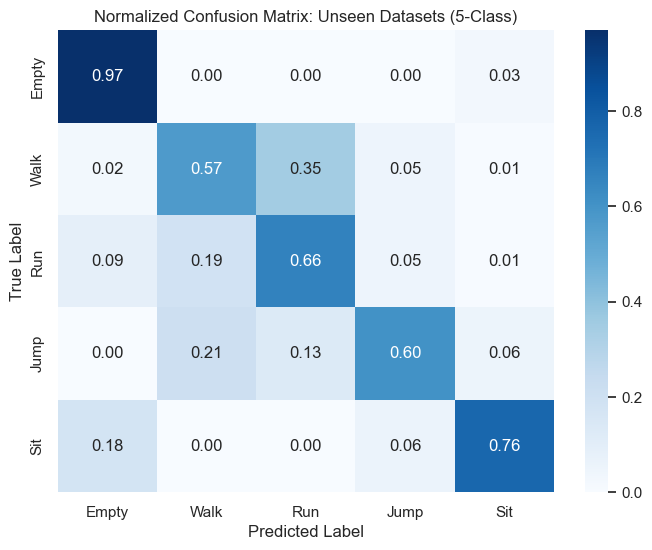

In [ ]:
from optuna.visualization import plot_optimization_history, plot_param_importances

def objective(trial):
    lr = trial.suggest_float("lr", 1e-4, 5e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    dropout = trial.suggest_float("dropout", 0.2, 0.5, step=0.1)
    model = LitSHARP(lr=lr, dropout=dropout, weight_decay=weight_decay)
    datamodule = OPERAnetDataModule(root_dir="doppler_traces", batch_size=batch_size)

    trainer = L.Trainer(
        max_epochs=HYP_EPOCHS, # Fast trial
        accelerator="auto",
        devices=1,
        logger=False, 
        enable_checkpointing=False,
        enable_progress_bar=False,
        callbacks=[PyTorchLightningPruningCallback(trial, monitor="val_acc")],
        enable_model_summary=False
    )

    trainer.fit(model, datamodule=datamodule)
    return trainer.callback_metrics["val_acc"].item()

""" def plot_confusion_matrix(true_labels, pred_labels): 
    if len(true_labels) == 0: return
    activity_names =['Empty', 'Walk', 'Run', 'Jump', 'Sit', 'Stand', 'Sit/Stand', 'Gym']
    
    # Forces 8x8 matrix to prevent crashes on missing classes
    cm = confusion_matrix(true_labels, pred_labels, labels=range(8))
    cm_perc = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-8)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_perc, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=activity_names, yticklabels=activity_names)
    plt.title('Normalized Confusion Matrix: Unseen Datasets')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show() """ # FOR 8 ACTIVITIES
    
def plot_confusion_matrix(true_labels, pred_labels):
    if len(true_labels) == 0: return
    
    # FIX 3: Update the names to match your new label_map
    activity_names = ['Empty', 'Walk', 'Run', 'Jump', 'Sit']
    
    # Force a 5x5 matrix
    cm = confusion_matrix(true_labels, pred_labels, labels=range(5))
    cm_perc = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-8)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_perc, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=activity_names, yticklabels=activity_names)
    plt.title('Normalized Confusion Matrix: Unseen Datasets (5-Class)')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

if __name__ == "__main__":
    torch.set_float32_matmul_precision('high')
    
    print("\n--- OPTIMIZING HYPERPARAMETERS ---")
    study = optuna.create_study(direction="maximize", pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=5))
    study.optimize(objective, n_trials=N_TRIALS)
    # 1. Print a detailed text summary of the best trial
    print("\n--- OPTUNA STUDY RESULTS ---")
    best_trial = study.best_trial
    
    print(f"Best Validation Accuracy: {best_trial.value:.4f}")
    print("Best Parameters:")
    for key, value in best_trial.params.items():
        print(f"    {key}: {value}")

    # 2. Visualize the results directly in the notebook
    try:
        # Shows how the accuracy improved over the 10 trials
        history_fig = plot_optimization_history(study)
        history_fig.show()
        
        # Shows which parameter (lr, batch_size, weight_decay, dropout) had the biggest impact
        importance_fig = plot_param_importances(study)
        importance_fig.show()
    except Exception as e:
        print(f"Could not render Optuna charts: {e}")
    
    print("\n--- BEST PARAMS FOUND ---")
    print(study.best_params)
    
    # --- DEFINE MANUAL PARAMS ---
    # manual_params = {
    #    "lr": 1e-3,
    #    "batch_size": 64,
    #    "weight_decay": 1e-4,
    #    "dropout": 0.3
    # }
    
    # --- USE MANUAL PARAMS ---
    # dm = OPERAnetDataModule(root_dir="doppler_traces", batch_size=manual_params["batch_size"])
    # model = LitSHARP(
    #    lr=manual_params["lr"], 
    #    weight_decay=manual_params["weight_decay"], 
    #   dropout=manual_params["dropout"]
    # )
    
    dm = OPERAnetDataModule(root_dir="doppler_traces", batch_size=study.best_params["batch_size"])
    model = LitSHARP(lr=study.best_params["lr"], weight_decay=study.best_params["weight_decay"], dropout=study.best_params["dropout"])

    logger = CSVLogger("logs", name="sharp_experiment")
    checkpoint_callback = ModelCheckpoint(monitor="val_acc", dirpath="checkpoints", filename="best-sharp", mode="max")
    
    trainer = L.Trainer(
        max_epochs=TRAIN_EPOCHS,
        accelerator="auto",      
        devices=1,               
        callbacks=[checkpoint_callback],
        precision="16-mixed",     
        logger=logger
    )

    print("\n--- TRAINING FINAL MODEL ---")
    trainer.fit(model, datamodule=dm)

    print("\n--- TESTING ON S2-S7 COMBINED ---")
    trainer.test(model, datamodule=dm)

    # Plot final results
    plot_confusion_matrix(model.test_labels, model.test_preds)

Loading weights from checkpoints/best-sharp-v22.ckpt...


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


Setup 'test': 4437 test samples (4-antenna fusion)

--- RUNNING QUICK TEST ---


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Users\YeXiaoJun\anaconda3\envs\torch_env\lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: FutureWarning:

`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

c:\Users\YeXiaoJun\anaconda3\envs\torch_env\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: PossibleUserWarning:

The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.



Setup 'test': 4437 test samples (4-antenna fusion)
Testing DataLoader 0: 100%|██████████| 70/70 [00:02<00:00, 31.47it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     test_fusion_acc        0.7103899121284485
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


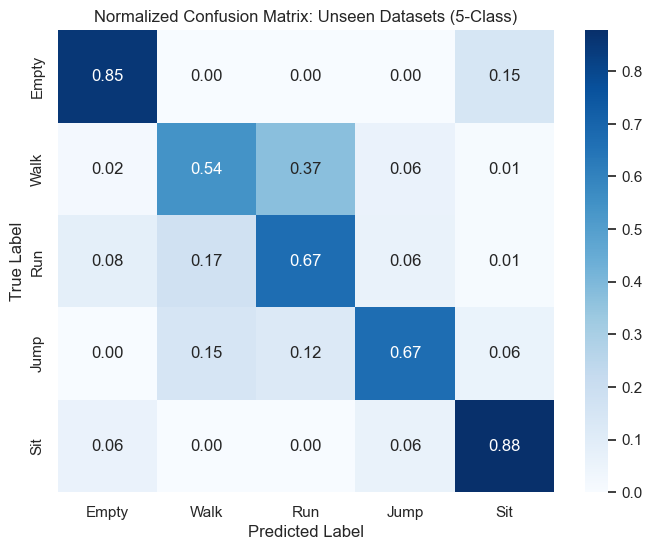

In [ ]:
""" import pytorch_lightning as L

# 1. Provide the exact path to your saved .ckpt file
# (Check your directory structure to confirm the exact name and path)
CHECKPOINT_PATH = "checkpoints/best-sharp-v22.ckpt" 

# 2. Load the model directly from the weights file
# Lightning automatically restores the architecture and the exact hyperparameters (lr, dropout, etc.)
print(f"Loading weights from {CHECKPOINT_PATH}...")
model = LitSHARP.load_from_checkpoint(CHECKPOINT_PATH)

# Put the model into evaluation mode (disables dropout, freezes batch norm)
model.eval() 

# 3. Initialize your DataModule for testing
# (You don't need to specify learning rates or train sets here, just the batch size for testing)
dm = OPERAnetDataModule(root_dir="doppler_traces", batch_size=64)

# Force the DataModule to run its setup for the "test" stage
# This loads S2-S7 (or whatever you set in your DataModule's test_ds)
dm.setup(stage="test") 

# 4. Create a lightweight Trainer strictly for testing
tester = L.Trainer(
    accelerator="auto", 
    devices=1, 
    logger=False,                 # No need to log to CSV just for a quick test
    enable_model_summary=False    # Keeps console output clean
)

# 5. Run the test!
print("\n--- RUNNING QUICK TEST ---")
tester.test(model, datamodule=dm)

# 6. (Optional) Plot the confusion matrix again
plot_confusion_matrix(model.test_labels, model.test_preds) """

Plotting metrics from: logs/sharp_experiment\version_22


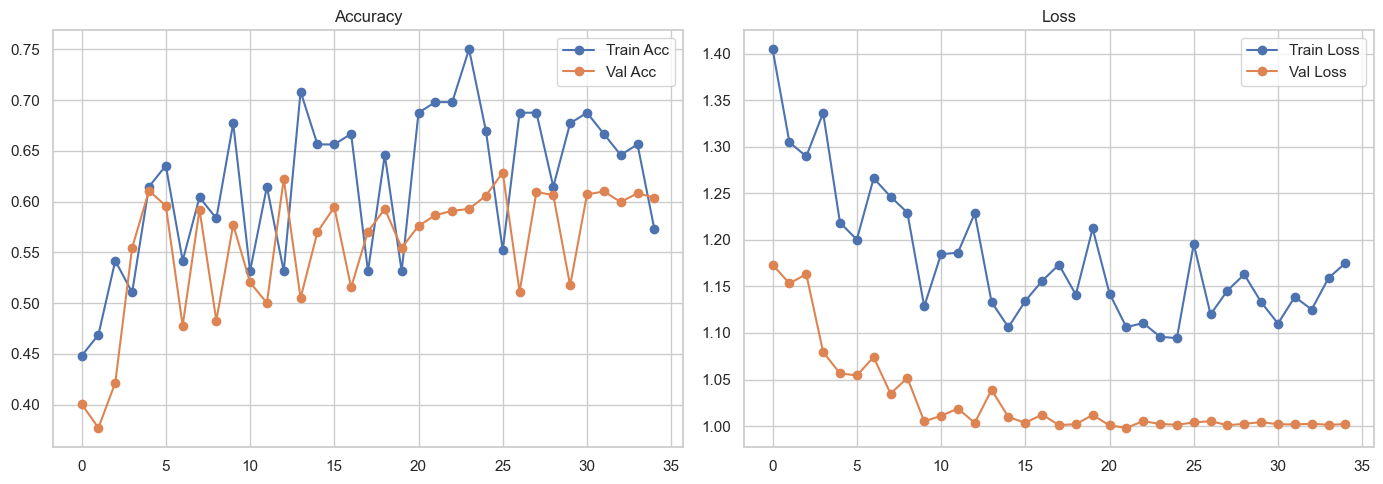

In [59]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_latest_learning_curves(base_log_dir):
    # 1. Automatically find the folder with the highest version number
    version_folders = glob.glob(os.path.join(base_log_dir, "version_*"))
    if not version_folders:
        print(f"No version folders found in {base_log_dir}")
        return
        
    latest_version = max(version_folders, key=lambda x: int(x.split('_')[-1]))
    metrics_path = os.path.join(latest_version, "metrics.csv")
    
    print(f"Plotting metrics from: {latest_version}")
    
    if not os.path.exists(metrics_path):
        print("metrics.csv not found yet. Has the model started training?")
        return
        
    df = pd.read_csv(metrics_path)
    
    # 2. Fix potential NaN issues in the epoch column
    # Lightning logs can have NaNs in the epoch column for step-level training metrics.
    # We backfill so training steps are associated with the correct epoch.
    df['epoch'] = df['epoch'].bfill()
    df_epoch = df.groupby('epoch').mean().reset_index()
    
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # --- Accuracy ---
    if 'train_acc' in df_epoch.columns:
        axes[0].plot(df_epoch['epoch'], df_epoch['train_acc'], label='Train Acc', marker='o')
    if 'val_acc' in df_epoch.columns:
        axes[0].plot(df_epoch['epoch'], df_epoch['val_acc'], label='Val Acc', marker='o')
    axes[0].set_title('Accuracy')
    axes[0].legend()
    
    # --- Loss ---
    if 'train_loss' in df_epoch.columns:
        axes[1].plot(df_epoch['epoch'], df_epoch['train_loss'], label='Train Loss', marker='o')
    if 'val_loss' in df_epoch.columns:
        axes[1].plot(df_epoch['epoch'], df_epoch['val_loss'], label='Val Loss', marker='o')
    axes[1].set_title('Loss')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

# Run this after training is finished
plot_latest_learning_curves("logs/sharp_experiment")

Loading training data for sets: ['S1']...
Loaded 6472 train samples.
Setup 'fit': 4854 train, 1618 val
Setup 'test': 4437 test samples (4-antenna fusion)


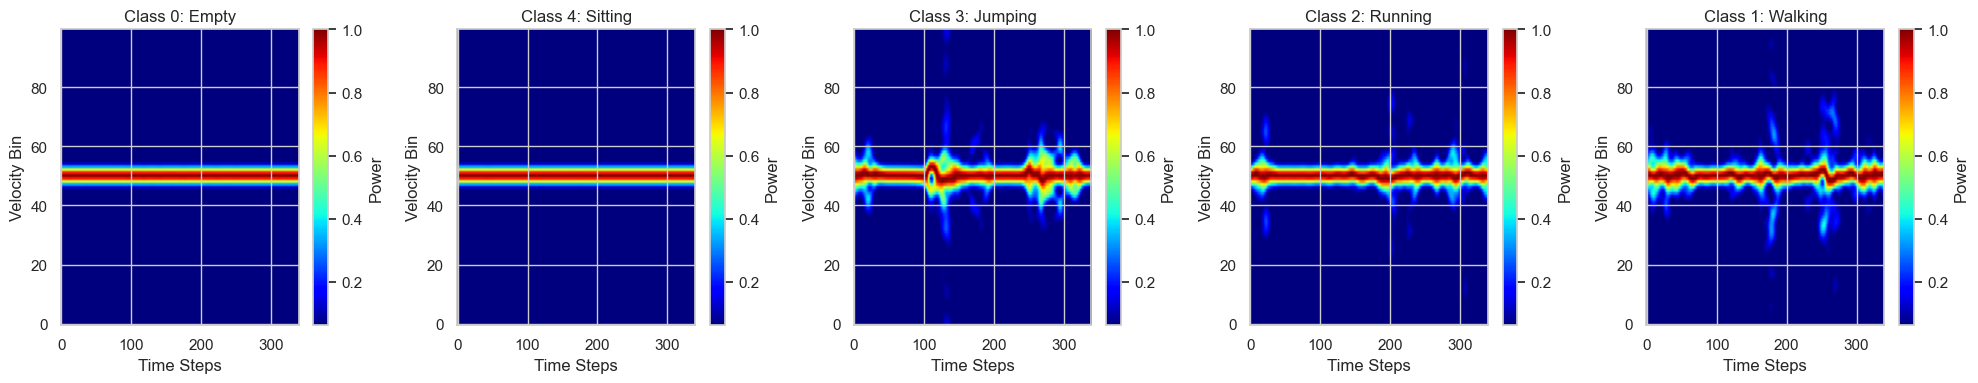

In [60]:
def plot_sample_activities(dataset, label_map):
    # Dynamically find the number of target classes
    num_classes = len(label_map)
    
    # Map the letters directly to their full names dynamically
    letter_to_name = {
        'E': 'Empty', 'W': 'Walking', 'R': 'Running', 'J': 'Jumping',
        'S': 'Sitting', 'L': 'Standing', 'C': 'Sit/Stand', 'H': 'Gym'
    }
    
    # Create {ID: Name} mapping using your actual label_map
    id_to_name = {v: letter_to_name[k] for k, v in label_map.items()}
    
    found_classes = set()
    
    # Adjust figure size based on how many classes we have
    cols = 4 if num_classes > 5 else 5
    rows = (num_classes + cols - 1) // cols
    plt.figure(figsize=(4 * cols, 4 * rows))
    
    count = 0
    # Search for one example of each class
    for i in range(len(dataset)):
        x, y = dataset[i]
        label = y.item()
        
        if label not in found_classes:
            found_classes.add(label)
            count += 1
            
            plt.subplot(rows, cols, count)
            # Remove channel dim and transpose so Time is X and Velocity is Y
            plt.imshow(x.squeeze().numpy().T, aspect='auto', origin='lower', cmap='jet')
            
            plt.title(f"Class {label}: {id_to_name[label]}")
            plt.xlabel("Time Steps")
            plt.ylabel("Velocity Bin")
            plt.colorbar(label="Power") # Added a colorbar to see the threshold!
            
            # Dynamically break when we find exactly the number of classes in the map
            if len(found_classes) == num_classes: 
                break
            
    plt.tight_layout()
    plt.show()

# --- HOW TO RUN IT ---
# Make sure to pass your current 5-class dictionary!
CURRENT_LABEL_MAP = {'E': 0, 'W': 1, 'R': 2, 'J': 3, 'S': 4}

dm = OPERAnetDataModule(root_dir="doppler_traces")
dm.setup()

plot_sample_activities(dm.train_ds, CURRENT_LABEL_MAP)